# Thực hành Buổi 07: Feature Engineering & RFM Customer Analytics

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Pandas, NumPy, Scikit-Learn

**Đầu vào ➔ Đầu ra:** `customer_churn.csv` + dataset sạch của Bài 6 ➔ Feature Matrix sẵn sàng cho Machine Learning (`data/processed/feature_matrix.parquet`)

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.
> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` trước — buổi này đọc `data/processed/enterprise_transactions_clean.parquet` và `data/raw/customer_churn.csv` do Bài 6 sinh ra.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.0


# BÀI 7 — FEATURE ENGINEERING & RFM CUSTOMER ANALYTICS

**Mục tiêu:** từ dữ liệu giao dịch sạch (Bài 6) + hồ sơ `customer_churn.csv`, xây dựng **Feature Matrix cấp khách hàng sẵn sàng cho Machine Learning**, với trung tâm là bộ chỉ số **RFM**:

| Chỉ số | Nghĩa | Cách tính |
|:---|:---|:---|
| **R — Recency** | mua gần đây chưa? | số ngày từ lần mua cuối đến mốc phân tích |
| **F — Frequency** | mua thường xuyên không? | tổng số giao dịch |
| **M — Monetary** | chi bao nhiêu tiền? | tổng giá trị giao dịch |

## 7.1. Nạp dữ liệu

In [2]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
kh = pd.read_csv(RAW / "customer_churn.csv")
# Chỉ tính hành vi mua trên giao dịch hoàn tất
tx_ht = tx[tx["status"] == "HOAN_TAT"].copy()
print(f"Giao dịch hoàn tất: {len(tx_ht):,} | Khách hàng trong hồ sơ: {len(kh):,}")
kh.head()

Giao dịch hoàn tất: 57,882 | Khách hàng trong hồ sơ: 8,000


,customer_id,age,gender,city,tenure_months,support_tickets,churn
0,C00001,47,Nữ,Hà Nội,15,1,0
1,C00002,32,Nam,Đà Nẵng,20,2,0
2,C00003,38,Nam,Cần Thơ,54,1,0
3,C00004,60,Nam,TP HCM,37,2,0
4,C00005,23,Nữ,TP HCM,39,0,0


## 7.2. Biến đổi đặc trưng ở cấp giao dịch

Hai biến đổi kinh điển trước khi tổng hợp:
- **Đặc trưng thời gian** rút từ `ts`: giờ, thứ, tháng, cờ cuối tuần — mô hình không đọc được timestamp thô.
- **Biến đổi log** cho biến tiền tệ lệch phải: `log1p` kéo phân phối về gần chuẩn, giúp thuật toán dựa trên khoảng cách hoạt động tốt hơn.

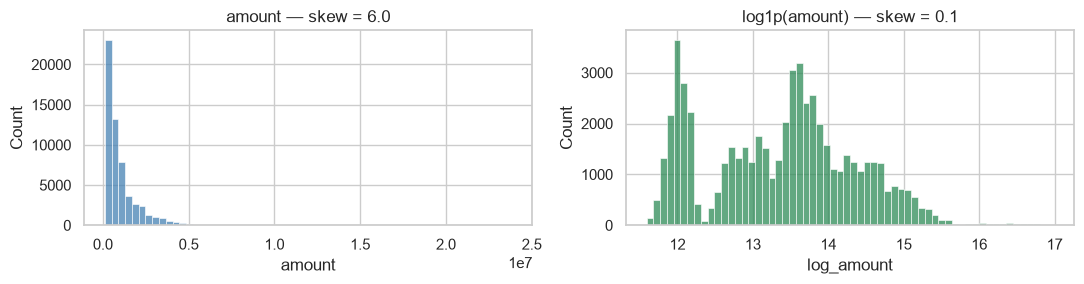

In [3]:
tx_ht["gio"] = tx_ht["ts"].dt.hour
tx_ht["thu"] = tx_ht["ts"].dt.dayofweek          # 0=Thứ 2 ... 6=Chủ nhật
tx_ht["thang"] = tx_ht["ts"].dt.to_period("M").astype(str)
tx_ht["cuoi_tuan"] = (tx_ht["thu"] >= 5).astype(int)
tx_ht["log_amount"] = np.log1p(tx_ht["amount"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(tx_ht["amount"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title(f"amount — skew = {tx_ht['amount'].skew():.1f}")
sns.histplot(tx_ht["log_amount"], bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(amount) — skew = {tx_ht['log_amount'].skew():.1f}")
plt.tight_layout(); plt.show()

## 7.3. Tính bảng RFM

Mốc phân tích (snapshot) = ngày cuối cùng trong dữ liệu + 1 ngày. Một lệnh `groupby().agg()` duy nhất tính cả ba chỉ số:

In [4]:
moc = tx_ht["ts"].max() + pd.Timedelta(days=1)
rfm = (tx_ht.groupby("customer_id")
       .agg(recency=("ts", lambda s: (moc - s.max()).days),
            frequency=("transaction_id", "size"),
            monetary=("amount", "sum")))
print(f"Mốc phân tích: {moc:%d/%m/%Y} | Số KH có giao dịch: {len(rfm):,}")
rfm.describe()

Mốc phân tích: 10/11/2025 | Số KH có giao dịch: 7,858


,recency,frequency,monetary
count,"7,858.00","7,858.00","7,858.00"
mean,60.51,7.37,"7,693,521.32"
std,61.13,14.62,"15,224,203.20"
min,1.00,1.00,"118,150.00"
25%,15.00,3.00,"2,424,287.50"
50%,40.00,5.00,"4,758,400.00"
75%,86.00,8.00,"8,499,050.00"
max,311.00,643.00,"628,184,874.65"


**Chấm điểm 1–5** bằng ngũ phân vị (`qcut`): điểm 5 luôn là "tốt nhất" — Recency càng NHỎ càng tốt (labels đảo), Frequency/Monetary càng LỚN càng tốt. Ghép ba điểm thành phân khúc khách hàng:

In [5]:
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5,
                   labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

def phan_khuc(r):
    if r["R"] >= 4 and r["F"] >= 4: return "Khách VIP"
    if r["R"] >= 4 and r["F"] <= 2: return "Khách mới"
    if r["R"] <= 2 and r["F"] >= 4: return "Nguy cơ rời bỏ"
    if r["R"] <= 2 and r["F"] <= 2: return "Đã ngủ đông"
    return "Trung bình"
rfm["phan_khuc"] = rfm.apply(phan_khuc, axis=1)

bang_pk = (rfm.groupby("phan_khuc")
           .agg(so_KH=("R", "size"), R_tb=("recency", "mean"),
                F_tb=("frequency", "mean"), M_tb=("monetary", "mean"))
           .sort_values("so_KH", ascending=False))
bang_pk.round(1)

,so_KH,R_tb,F_tb,M_tb
phan_khuc,,,,
Trung bình,2809,47.60,5.70,"5,905,318.10"
Đã ngủ đông,1945,135.50,2.50,"2,620,210.70"
Khách VIP,1885,11.80,16.30,"16,927,916.90"
Khách mới,651,13.90,2.90,"3,090,774.30"
Nguy cơ rời bỏ,568,82.70,8.00,"8,538,951.90"


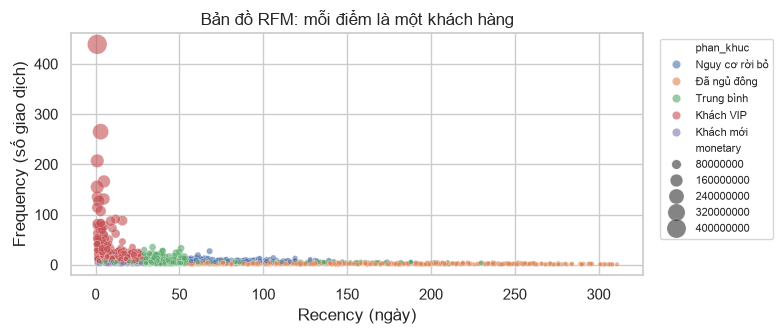

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.scatterplot(data=rfm.sample(3000, random_state=0), x="recency", y="frequency",
                hue="phan_khuc", size="monetary", sizes=(10, 200),
                alpha=0.6, ax=ax)
ax.set_title("Bản đồ RFM: mỗi điểm là một khách hàng")
ax.set_xlabel("Recency (ngày)"); ax.set_ylabel("Frequency (số giao dịch)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 7.4. Đặc trưng hành vi bổ sung

RFM là xương sống nhưng chưa đủ. Bổ sung các đặc trưng tổng hợp mà mô hình churn rất "thích":

In [7]:
hanh_vi = (tx_ht.groupby("customer_id")
    .agg(gia_tri_don_tb=("amount", "mean"),
         so_nganh_hang=("category", "nunique"),
         ty_le_online=("channel", lambda s: s.eq("Online").mean()),
         ty_le_cuoi_tuan=("cuoi_tuan", "mean"),
         so_chi_nhanh=("branch", "nunique")))
# Tỷ lệ hoàn trả tính trên TOÀN BỘ giao dịch (kể cả HOAN_TRA)
hoan_tra = tx.groupby("customer_id")["status"].apply(
    lambda s: s.eq("HOAN_TRA").mean()).rename("ty_le_hoan_tra")
hanh_vi = hanh_vi.join(hoan_tra)
hanh_vi.head()

,gia_tri_don_tb,so_nganh_hang,ty_le_online,ty_le_cuoi_tuan,so_chi_nhanh,ty_le_hoan_tra
customer_id,,,,,,
C00001,"976,959.37",6,0.46,0.31,5,0.03
C00002,"962,195.92",6,0.45,0.24,5,0.04
C00003,"1,077,741.46",6,0.44,0.28,5,0.03
C00004,"1,052,217.67",6,0.41,0.30,5,0.04
C00005,"1,042,177.06",6,0.46,0.29,5,0.03


## 7.5. Ghép thành Feature Matrix và chuẩn hóa cho ML

Ba việc cuối: **(1)** ghép hồ sơ khách hàng với RFM + hành vi (khách không có giao dịch nào được điền giá trị "trắng" hợp lý, kèm cờ `chua_tung_mua`); **(2)** mã hóa one-hot các biến phân loại; **(3)** chuẩn hóa `StandardScaler`.

In [8]:
from sklearn.preprocessing import StandardScaler

fm = (kh.set_index("customer_id")
        .join(rfm[["recency", "frequency", "monetary", "R", "F", "M", "phan_khuc"]])
        .join(hanh_vi))
fm["chua_tung_mua"] = fm["frequency"].isna().astype(int)
fm = fm.fillna({"recency": 999, "frequency": 0, "monetary": 0, "R": 1, "F": 1, "M": 1,
                "phan_khuc": "Chưa mua", "gia_tri_don_tb": 0, "so_nganh_hang": 0,
                "ty_le_online": 0, "ty_le_cuoi_tuan": 0, "so_chi_nhanh": 0,
                "ty_le_hoan_tra": 0})

# One-hot cho biến phân loại
fm = pd.get_dummies(fm, columns=["gender", "city", "phan_khuc"], dtype=int)

# Chuẩn hóa các cột số (trừ nhãn churn và các cột nhị phân)
cot_so = ["age", "tenure_months", "support_tickets", "recency", "frequency",
          "monetary", "gia_tri_don_tb", "so_nganh_hang", "ty_le_online",
          "ty_le_cuoi_tuan", "so_chi_nhanh", "ty_le_hoan_tra"]
fm[cot_so] = StandardScaler().fit_transform(fm[cot_so])

fm.to_parquet(PROCESSED / "feature_matrix.parquet")
print(f"Feature Matrix: {fm.shape[0]:,} khách hàng x {fm.shape[1]} cột (nhãn: churn)")
fm.head()

Feature Matrix: 8,000 khách hàng x 30 cột (nhãn: churn)


,age,tenure_months,support_tickets,churn,recency,frequency,monetary,R,F,M,...,city_Hà Nội,city_Hải Phòng,city_TP HCM,city_Đà Nẵng,phan_khuc_Chưa mua,phan_khuc_Khách VIP,phan_khuc_Khách mới,phan_khuc_Nguy cơ rời bỏ,phan_khuc_Trung bình,phan_khuc_Đã ngủ đông
customer_id,,,,,,,,,,,,,,,,,,,,,
C00001,0.18,-0.88,-0.19,0,-0.55,43.79,41.04,5.00,5.00,5.00,...,1,0,0,0,0,1,0,0,0,0
C00002,-0.80,-0.60,0.74,0,-0.55,29.74,27.43,5.00,5.00,5.00,...,0,0,0,1,0,1,0,0,0,0
C00003,-0.40,1.37,-0.19,0,-0.55,23.19,24.02,5.00,5.00,5.00,...,0,0,0,0,0,1,0,0,0,0
C00004,1.03,0.39,0.74,0,-0.55,20.58,20.79,5.00,5.00,5.00,...,0,0,1,0,0,1,0,0,0,0
C00005,-1.38,0.51,-1.12,0,-0.54,17.75,17.76,5.00,5.00,5.00,...,0,0,1,0,0,1,0,0,0,0


**Kiểm chứng "sẵn sàng cho ML":** huấn luyện nhanh một mô hình Logistic Regression — nếu pipeline đặc trưng tốt, mô hình phải vượt xa mức đoán mò (AUC = 0.5):

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = fm.drop(columns="churn"); y = fm["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)
mo_hinh = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
auc = roc_auc_score(y_te, mo_hinh.predict_proba(X_te)[:, 1])
print(f"AUC trên tập kiểm tra: {auc:.3f}  (đoán mò = 0.500)")

anh_huong = pd.Series(mo_hinh.coef_[0], index=X.columns)
anh_huong.reindex(anh_huong.abs().sort_values(ascending=False).index).head(8) \
    .rename("hệ số (>0 đẩy churn, <0 giữ chân)").to_frame()

AUC trên tập kiểm tra: 0.748  (đoán mò = 0.500)


,"hệ số (>0 đẩy churn, <0 giữ chân)"
frequency,-2.88
tenure_months,-0.52
support_tickets,0.49
phan_khuc_Khách VIP,-0.27
gender_Nam,-0.23
gender_Nữ,-0.23
phan_khuc_Nguy cơ rời bỏ,-0.22
city_Hà Nội,-0.16


---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (RFM): Tính bảng RFM riêng cho từng `channel` (Online và Cửa hàng). Phân khúc "Khách VIP" ở hai kênh khác nhau thế nào về Monetary trung bình?

In [10]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Feature): Thêm đặc trưng `so_ngay_giua_2_lan_mua_tb` (khoảng cách trung bình giữa hai lần mua liên tiếp của mỗi khách, tính bằng ngày; khách mua 1 lần điền 999). Gợi ý: `groupby().ts.apply(lambda s: s.sort_values().diff().dt.days.mean())`.

In [11]:
# --- BÀI TẬP 2 ---
